# Phase 2 — Exploratory Data Analysis

**Goal:** Develop deep understanding of the IEEE-CIS Fraud Detection dataset before building features and models.

**Key questions:**
1. How severe is the class imbalance, and what does it imply for evaluation metrics?
2. What's the missing-data pattern across the 435 features?
3. Which categorical and numerical features show the strongest separation between fraud and non-fraud?
4. Are there temporal patterns in fraud occurrence?
5. What feature engineering opportunities are visible from the raw data?

**Dataset:** 590,540 training transactions, 3.50% fraud rate (1 fraud per 28 transactions).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

# Paths
RAW = Path("../data/raw")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Saving figures to: {FIGURES.resolve()}")

Setup complete
Saving figures to: C:\Projects\fraud-detection-system\reports\figures


In [2]:
def reduce_mem_usage(df):
    """Downcast numeric columns to save memory."""
    start_mem = df.memory_usage(deep=True).sum() / 1e9
    
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage(deep=True).sum() / 1e9
    print(f"Memory: {start_mem:.2f} GB → {end_mem:.2f} GB ({(1 - end_mem/start_mem)*100:.1f}% reduction)")
    return df

# Load and optimize
print("Loading train_transaction.csv...")
train_txn = pd.read_csv(RAW / "train_transaction.csv")
train_txn = reduce_mem_usage(train_txn)

print("\nLoading train_identity.csv...")
train_id = pd.read_csv(RAW / "train_identity.csv")
train_id = reduce_mem_usage(train_id)

print(f"\nTransactions: {train_txn.shape}")
print(f"Identity:     {train_id.shape}")

Loading train_transaction.csv...
Memory: 2.20 GB → 1.30 GB (40.9% reduction)

Loading train_identity.csv...
Memory: 0.17 GB → 0.15 GB (8.4% reduction)

Transactions: (590540, 394)
Identity:     (144233, 41)


In [3]:
# Merge transactions with identity on TransactionID (left join — many txns have no identity info)
df = train_txn.merge(train_id, on='TransactionID', how='left')

print(f"Merged shape: {df.shape}")
print(f"Transactions with identity info: {df['id_01'].notna().sum():,} ({df['id_01'].notna().mean()*100:.1f}%)")
print(f"Transactions without identity:   {df['id_01'].isna().sum():,} ({df['id_01'].isna().mean()*100:.1f}%)")

Merged shape: (590540, 434)
Transactions with identity info: 144,233 (24.4%)
Transactions without identity:   446,307 (75.6%)


## B. Class Distribution and Missing Data

The two foundational data characteristics that drive every downstream modeling decision.

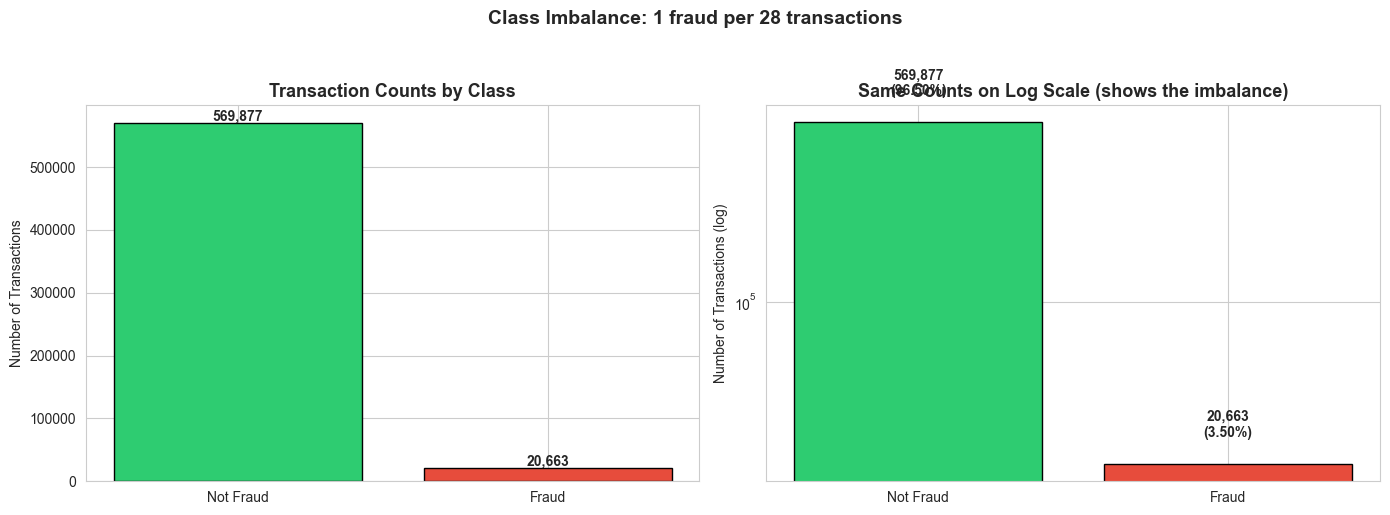

Saved to ..\reports\figures\01_class_balance.png


In [6]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts
class_counts = df['isFraud'].value_counts().sort_index()
labels = ['Not Fraud', 'Fraud']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Transaction Counts by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Right: log scale to actually see the fraud bar
axes[1].bar(labels, class_counts.values, color=colors, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Same Counts on Log Scale (shows the imbalance)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Transactions (log)')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v * 1.3, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontweight='bold')

plt.suptitle(f'Class Imbalance: 1 fraud per {int(len(df) / df["isFraud"].sum())} transactions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "01_class_balance.png", bbox_inches='tight')
plt.show()
print(f"Saved to {FIGURES / '01_class_balance.png'}")

Total columns: 434
Columns with >50% missing: 214
Columns with >90% missing: 12
Columns with 0% missing:   20


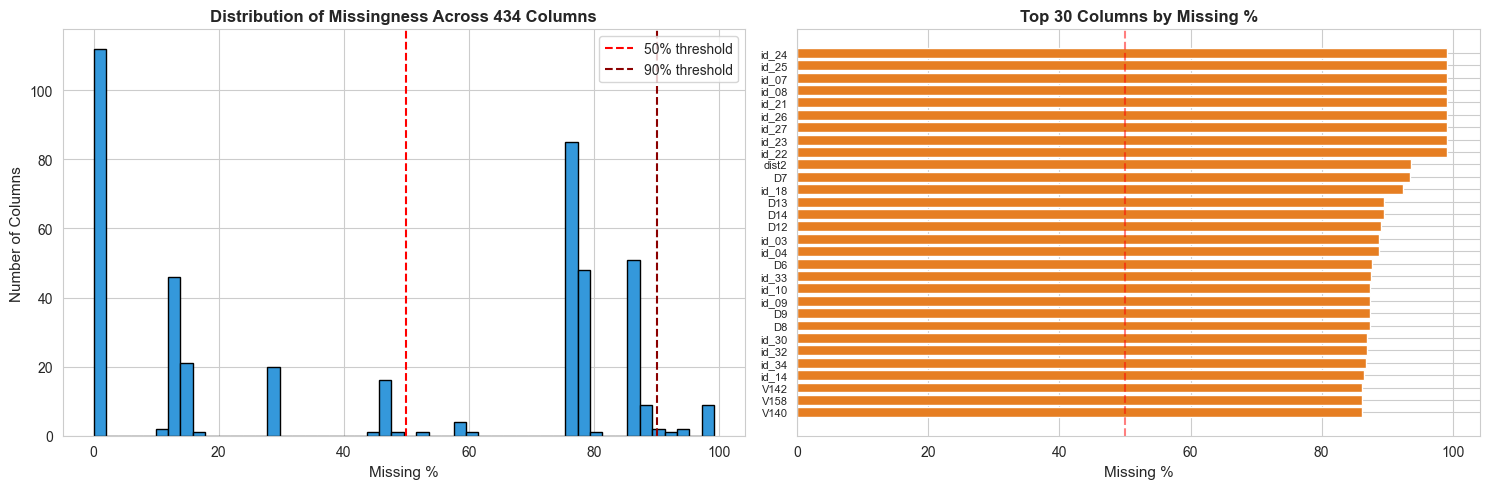


Saved to ..\reports\figures\02_missing_data.png


In [7]:
# Missing data: percentage null per column
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print(f"Total columns: {len(missing_pct)}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >90% missing: {(missing_pct > 90).sum()}")
print(f"Columns with 0% missing:   {(missing_pct == 0).sum()}")

# Distribution of missingness
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram of missing percentages
axes[0].hist(missing_pct.values, bins=50, color='#3498db', edgecolor='black')
axes[0].set_xlabel('Missing %', fontsize=11)
axes[0].set_ylabel('Number of Columns', fontsize=11)
axes[0].set_title('Distribution of Missingness Across 434 Columns', fontsize=12, fontweight='bold')
axes[0].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[0].axvline(90, color='darkred', linestyle='--', label='90% threshold')
axes[0].legend()

# Right: top 30 most-missing columns
top_missing = missing_pct.head(30)
axes[1].barh(range(len(top_missing)), top_missing.values, color='#e67e22')
axes[1].set_yticks(range(len(top_missing)))
axes[1].set_yticklabels(top_missing.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Missing %', fontsize=11)
axes[1].set_title('Top 30 Columns by Missing %', fontsize=12, fontweight='bold')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES / "02_missing_data.png", bbox_inches='tight')
plt.show()
print(f"\nSaved to {FIGURES / '02_missing_data.png'}")

**Key insight:** The dataset has bimodal missingness — most columns are either fully populated or heavily sparse (>50% null). This rules out naive imputation strategies. Our approach:

- **Tree-based models (LightGBM, XGBoost)** can handle NaN natively — no imputation needed for modeling
- **Missing indicators** will be engineered as features for high-importance sparse columns
- **Identity columns** (75.6% missing because most transactions don't have identity data) get special treatment — treat absence as a signal, not noise

## C. Transaction Amount and Categorical Patterns

Searching for separation between fraud and non-fraud across the core features.

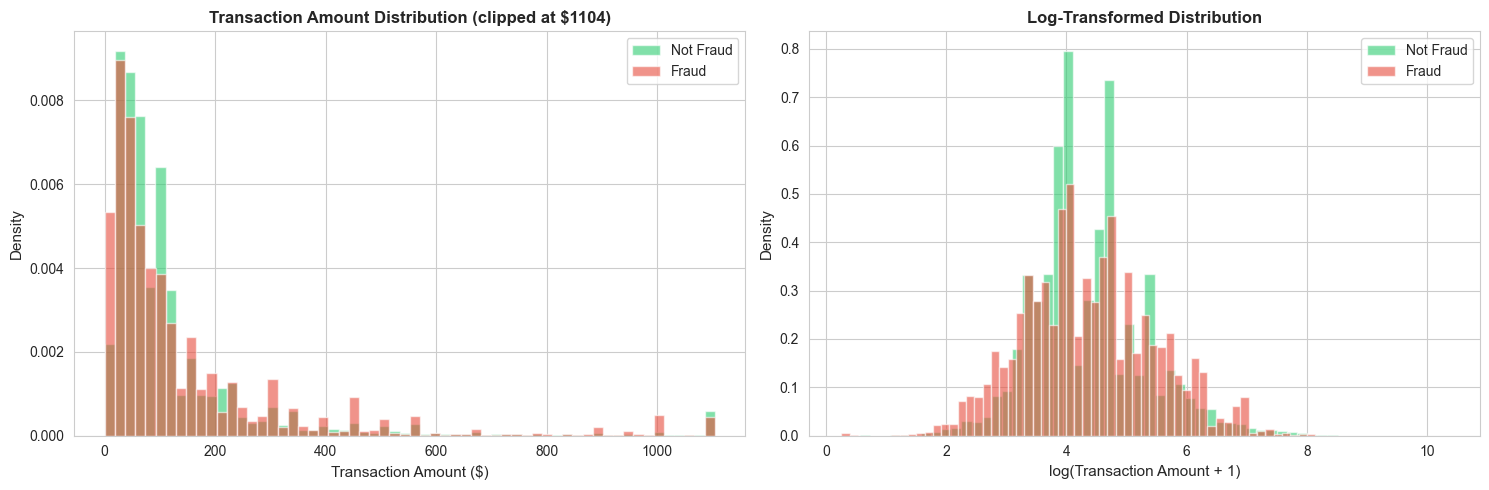


=== Transaction Amount Statistics ===
               mean  median         std   min           max
isFraud                                                    
0        134.509995    68.5  239.399994  0.25  31937.390625
1        149.240005    75.0  232.210007  0.29   5191.000000


In [8]:
# Transaction amount: distribution by class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: raw distribution (clipped at 99th percentile for visibility)
amt_clip = df['TransactionAmt'].quantile(0.99)
axes[0].hist(df[df['isFraud']==0]['TransactionAmt'].clip(upper=amt_clip), 
             bins=60, alpha=0.6, label='Not Fraud', color='#2ecc71', density=True)
axes[0].hist(df[df['isFraud']==1]['TransactionAmt'].clip(upper=amt_clip), 
             bins=60, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
axes[0].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title(f'Transaction Amount Distribution (clipped at ${amt_clip:.0f})', fontweight='bold')
axes[0].legend()

# Right: log-transformed
axes[1].hist(np.log1p(df[df['isFraud']==0]['TransactionAmt']), 
             bins=60, alpha=0.6, label='Not Fraud', color='#2ecc71', density=True)
axes[1].hist(np.log1p(df[df['isFraud']==1]['TransactionAmt']), 
             bins=60, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
axes[1].set_xlabel('log(Transaction Amount + 1)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Log-Transformed Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "03_transaction_amount.png", bbox_inches='tight')
plt.show()

# Statistical summary
print("\n=== Transaction Amount Statistics ===")
print(df.groupby('isFraud')['TransactionAmt'].agg(['mean', 'median', 'std', 'min', 'max']).round(2))

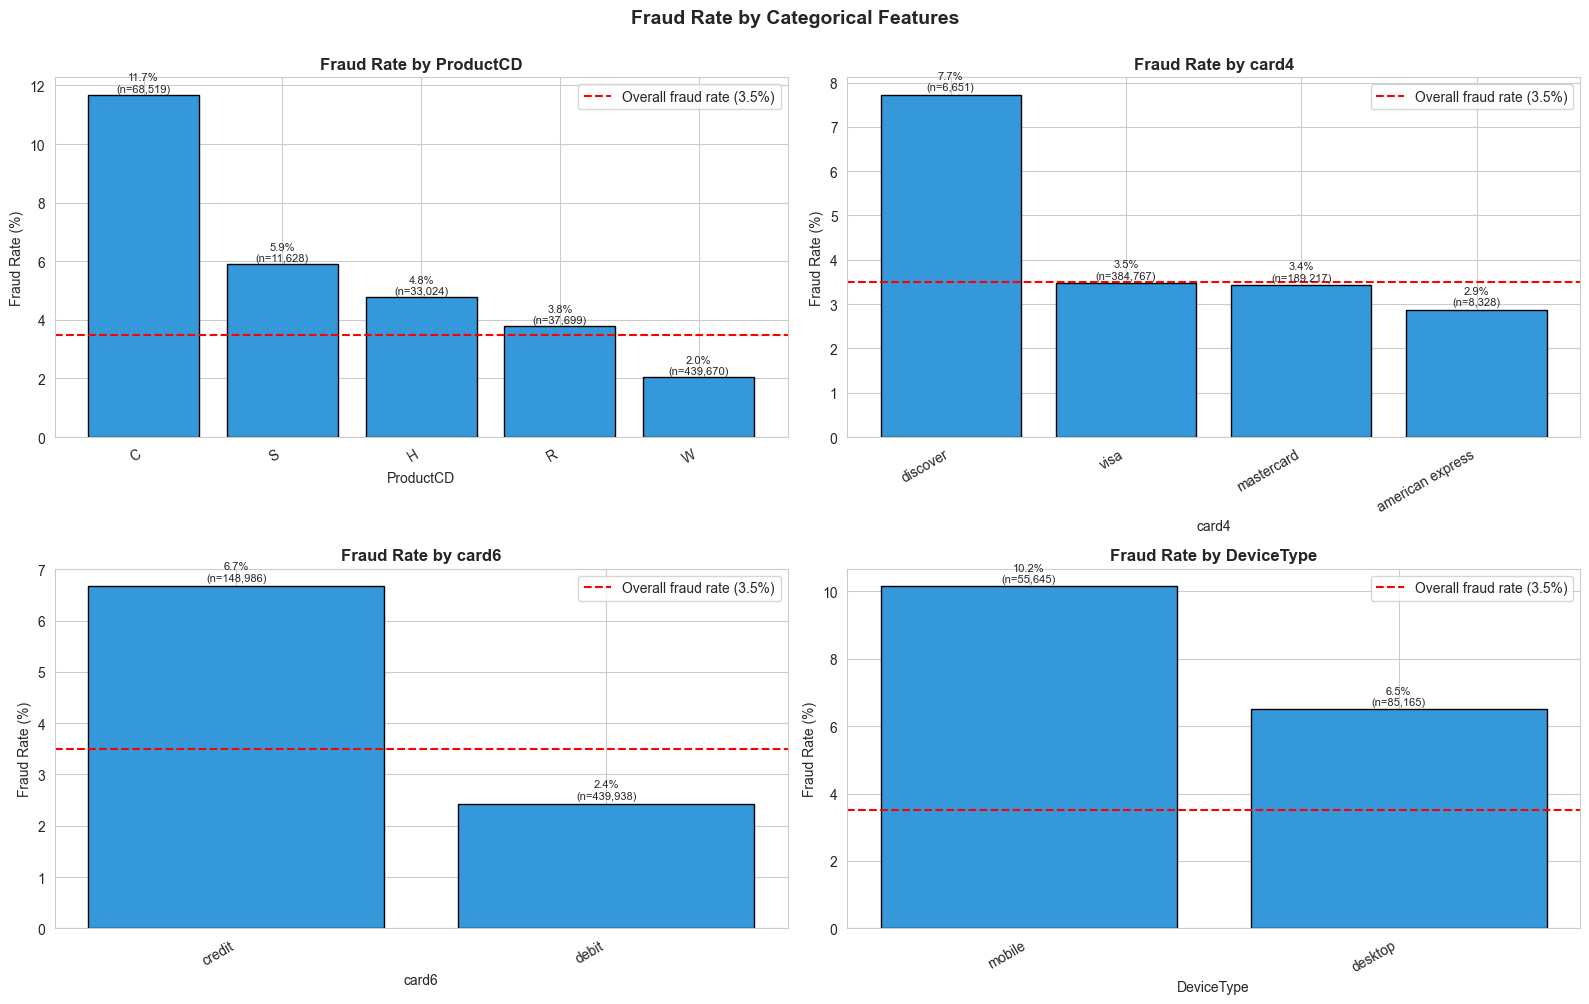

In [9]:
# Fraud rate by key categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

cat_features = ['ProductCD', 'card4', 'card6', 'DeviceType']

for ax, feat in zip(axes.flat, cat_features):
    # Fraud rate per category, only show categories with >100 transactions
    grp = df.groupby(feat).agg(
        fraud_rate=('isFraud', 'mean'),
        count=('isFraud', 'count')
    ).reset_index()
    grp = grp[grp['count'] >= 100].sort_values('fraud_rate', ascending=False)
    
    bars = ax.bar(grp[feat].astype(str), grp['fraud_rate'] * 100, color='#3498db', edgecolor='black')
    ax.axhline(3.50, color='red', linestyle='--', label='Overall fraud rate (3.5%)', linewidth=1.5)
    ax.set_title(f'Fraud Rate by {feat}', fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel(feat)
    ax.legend()
    
    # Annotate with count
    for bar, count in zip(bars, grp['count']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}%\n(n={count:,})', ha='center', fontsize=8)
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Fraud Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGURES / "04_categorical_fraud_rates.png", bbox_inches='tight')
plt.show()

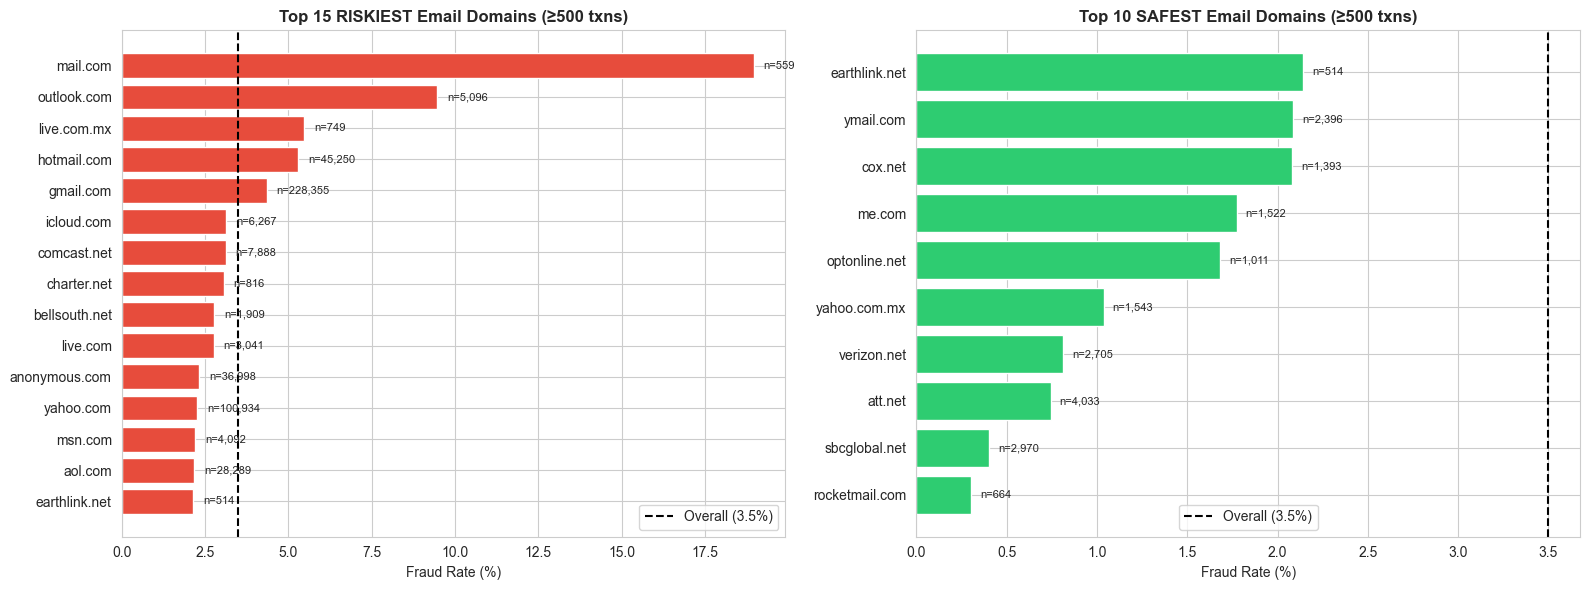


=== Top 5 RISKIEST email domains ===
P_emaildomain  fraud_rate  count
     mail.com    0.189624    559
  outlook.com    0.094584   5096
  live.com.mx    0.054740    749
  hotmail.com    0.052950  45250
    gmail.com    0.043542 228355

=== Top 5 SAFEST email domains ===
P_emaildomain  fraud_rate  count
earthlink.net    0.021401    514
    ymail.com    0.020868   2396
      cox.net    0.020818   1393
       me.com    0.017740   1522
optonline.net    0.016815   1011


In [10]:
# Email domain analysis — fraud rate by sender domain (P_emaildomain)
email_stats = df.groupby('P_emaildomain').agg(
    fraud_rate=('isFraud', 'mean'),
    count=('isFraud', 'count')
).reset_index()
email_stats = email_stats[email_stats['count'] >= 500].sort_values('fraud_rate', ascending=False)

# Top 15 riskiest and 10 safest
top_risky = email_stats.head(15)
top_safe = email_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_risky['P_emaildomain'], top_risky['fraud_rate'] * 100, color='#e74c3c')
axes[0].axvline(3.50, color='black', linestyle='--', label='Overall (3.5%)')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Top 15 RISKIEST Email Domains (≥500 txns)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].legend()
for i, (rate, count) in enumerate(zip(top_risky['fraud_rate']*100, top_risky['count'])):
    axes[0].text(rate + 0.3, i, f'n={count:,}', va='center', fontsize=8)

axes[1].barh(top_safe['P_emaildomain'], top_safe['fraud_rate'] * 100, color='#2ecc71')
axes[1].axvline(3.50, color='black', linestyle='--', label='Overall (3.5%)')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_title('Top 10 SAFEST Email Domains (≥500 txns)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].legend()
for i, (rate, count) in enumerate(zip(top_safe['fraud_rate']*100, top_safe['count'])):
    axes[1].text(rate + 0.05, i, f'n={count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "05_email_domain_fraud.png", bbox_inches='tight')
plt.show()

print("\n=== Top 5 RISKIEST email domains ===")
print(top_risky.head().to_string(index=False))
print("\n=== Top 5 SAFEST email domains ===")
print(top_safe.head().to_string(index=False))

## D. Temporal Patterns

`TransactionDT` is seconds since a reference start date. We'll derive hour-of-day, day-of-week, and look for temporal fraud patterns.

**Hypothesis:** Fraud should concentrate in off-hours (3-7 AM) when monitoring teams are less staffed and customers are asleep.

Date range: 2017-12-02 00:00:00 to 2018-06-01 23:58:51
Total days covered: 181


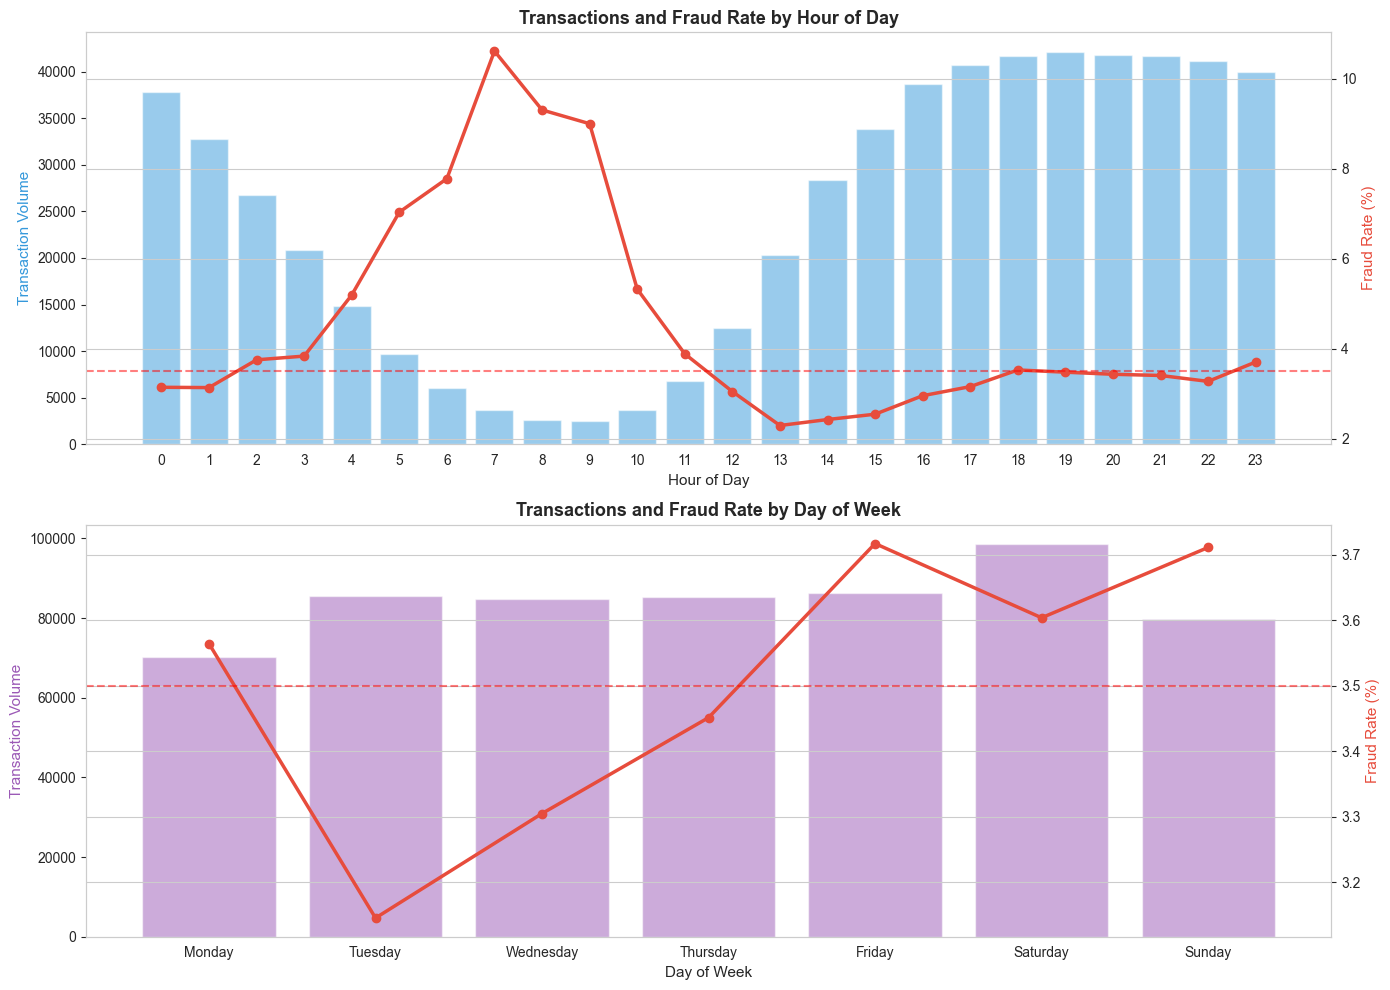


=== Fraud rate by hour (top 5 riskiest hours) ===
 hour  volume  fraud_rate
    7    3704    0.106102
    8    2591    0.093014
    9    2479    0.089956
    6    6007    0.077743
    5    9701    0.070302


In [12]:
# Convert TransactionDT (seconds from reference) into derived time features
# IEEE-CIS reference start: 2017-12-01 (common assumption from Kaggle discussion)
START_DATE = pd.Timestamp('2017-12-01')

df['datetime'] = START_DATE + pd.to_timedelta(df['TransactionDT'], unit='s')
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_week_name'] = df['datetime'].dt.day_name()
df['day_of_month'] = df['datetime'].dt.day

print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Total days covered: {(df['datetime'].max() - df['datetime'].min()).days}")

# Plot fraud rate vs transaction volume by hour
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Hourly: dual axis (volume + fraud rate)
hourly = df.groupby('hour').agg(
    volume=('isFraud', 'count'),
    fraud_rate=('isFraud', 'mean')
).reset_index()

ax1 = axes[0]
ax2 = ax1.twinx()

bars = ax1.bar(hourly['hour'], hourly['volume'], color='#3498db', alpha=0.5, label='Transaction Volume')
line = ax2.plot(hourly['hour'], hourly['fraud_rate'] * 100, color='#e74c3c', marker='o', 
                linewidth=2.5, label='Fraud Rate (%)')
ax2.axhline(3.50, color='red', linestyle='--', alpha=0.5, label='Overall Fraud Rate')

ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Transaction Volume', color='#3498db', fontsize=11)
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c', fontsize=11)
ax1.set_title('Transactions and Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.grid(False)

# Day of week
dow = df.groupby(['day_of_week', 'day_of_week_name']).agg(
    volume=('isFraud', 'count'),
    fraud_rate=('isFraud', 'mean')
).reset_index().sort_values('day_of_week')

ax3 = axes[1]
ax4 = ax3.twinx()
ax3.bar(dow['day_of_week_name'], dow['volume'], color='#9b59b6', alpha=0.5)
ax4.plot(dow['day_of_week_name'], dow['fraud_rate'] * 100, color='#e74c3c', marker='o', linewidth=2.5)
ax4.axhline(3.50, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Day of Week', fontsize=11)
ax3.set_ylabel('Transaction Volume', color='#9b59b6', fontsize=11)
ax4.set_ylabel('Fraud Rate (%)', color='#e74c3c', fontsize=11)
ax3.set_title('Transactions and Fraud Rate by Day of Week', fontsize=13, fontweight='bold')
ax3.grid(False)

plt.tight_layout()
plt.savefig(FIGURES / "06_temporal_patterns.png", bbox_inches='tight')
plt.show()

print("\n=== Fraud rate by hour (top 5 riskiest hours) ===")
print(hourly.nlargest(5, 'fraud_rate').to_string(index=False))

In [14]:
# Quick velocity check: how often does the same card transact multiple times in a short window?
# This is a preview of features we'll engineer properly in Phase 3

# Cards with highest transaction volume in the dataset
top_cards = df['card1'].value_counts().head(20)
print(f"Most active card1 IDs (out of {df['card1'].nunique():,} unique):")
print(top_cards.head(10))

# What's the fraud rate for these high-frequency cards?
high_freq_cards = df['card1'].value_counts()
high_freq = high_freq_cards[high_freq_cards >= 100].index  # cards with ≥100 transactions
low_freq = high_freq_cards[high_freq_cards < 5].index      # cards with <5 transactions

high_freq_fraud_rate = df[df['card1'].isin(high_freq)]['isFraud'].mean()
low_freq_fraud_rate = df[df['card1'].isin(low_freq)]['isFraud'].mean()

print(f"\nFraud rate, cards with ≥100 transactions: {high_freq_fraud_rate*100:.2f}%")
print(f"Fraud rate, cards with <5 transactions:   {low_freq_fraud_rate*100:.2f}%")
print(f"Lift: {low_freq_fraud_rate / high_freq_fraud_rate:.2f}x")

Most active card1 IDs (out of 13,553 unique):
card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
12695     7091
12544     6773
6019      6771
2803      6141
7585      5334
Name: count, dtype: int64

Fraud rate, cards with ≥100 transactions: 3.72%
Fraud rate, cards with <5 transactions:   3.39%
Lift: 0.91x


## E. Feature Correlations with Target

Quick preview of which features have the strongest linear relationship with fraud. This is NOT a substitute for proper feature importance from a trained model (LightGBM in Phase 4), but it surfaces obvious candidates and confirms our intuitions from sections C and D.

Numeric columns: 406


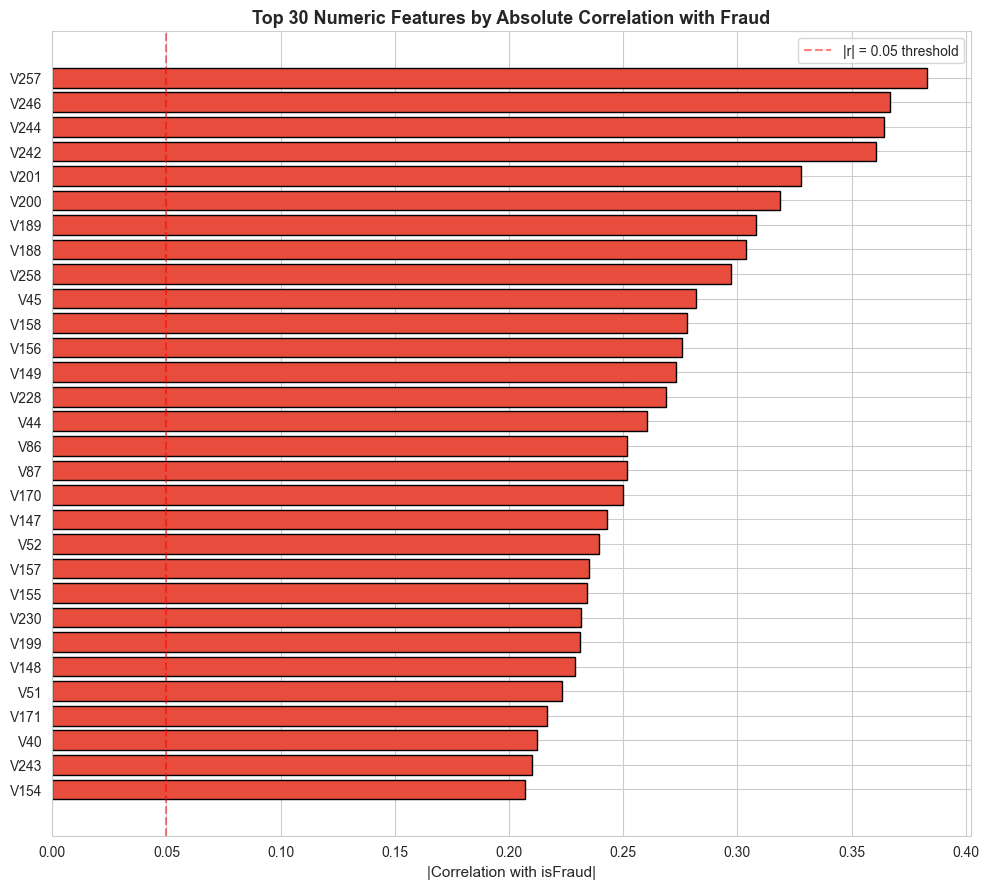


=== Top 15 features by |correlation| with isFraud ===
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376

Features with |r| > 0.05: 176
Features with |r| > 0.10: 119


In [15]:
# Numeric features only for correlation
numeric_df = df.select_dtypes(include=[np.number])
print(f"Numeric columns: {numeric_df.shape[1]}")

# Compute correlation of every numeric feature with isFraud
# Drop isFraud itself from the result
target_corr = numeric_df.corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

# Top 30 features by absolute correlation
top_corr = target_corr.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if v > 0.05 else '#3498db' for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='black')
ax.set_xlabel('|Correlation with isFraud|', fontsize=11)
ax.set_title('Top 30 Numeric Features by Absolute Correlation with Fraud', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.axvline(0.05, color='red', linestyle='--', alpha=0.5, label='|r| = 0.05 threshold')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "07_feature_correlations.png", bbox_inches='tight')
plt.show()

print("\n=== Top 15 features by |correlation| with isFraud ===")
print(target_corr.head(15).to_string())
print(f"\nFeatures with |r| > 0.05: {(target_corr > 0.05).sum()}")
print(f"Features with |r| > 0.10: {(target_corr > 0.10).sum()}")

## Summary of EDA Insights

### Dataset characteristics
- **590,540 training transactions** with **434 features** (after merging transactions + identity tables)
- **3.50% fraud rate** (20,663 frauds) — severe class imbalance, 1:27 ratio
- **75.6% of transactions have no identity information** — absence-of-identity itself is a signal to model
- **214 of 434 columns are >50% missing** — bimodal missingness pattern (most columns are either fully populated or heavily sparse)
- **181 days of data** (Dec 2017 – Jun 2018)

### Modeling implications
1. **Tree-based models (LightGBM, XGBoost) are the right choice.** They handle NaN natively, capture feature interactions, and are robust to the mixed numeric/categorical schema.
2. **Evaluation must NOT use accuracy.** A trivial "always predict not-fraud" model achieves 96.5% accuracy. Use PR-AUC, recall@fixed-FPR, and a business-cost-weighted threshold.
3. **Class weighting (`scale_pos_weight ≈ 28`) over resampling.** Tree models with class weights typically outperform SMOTE for this kind of severe imbalance.

### Key feature signals discovered
| Signal | Finding | Implication |
|---|---|---|
| **ProductCD** | `C` has 11.7% fraud (3.3x baseline); `W` has 2.0% | High-importance feature |
| **Card type** | Credit cards 6.7% fraud, debit cards 2.4% | Card type is a strong signal |
| **Card brand** | Discover 7.7% fraud vs Amex 2.9% | Brand matters |
| **Device type** | Mobile 10.2% vs desktop 6.5% | Engineer mobile-specific features |
| **Email domain** | `mail.com` 18.96% fraud; ISP-tied domains (cox.net, earthlink.net) under 2.5% | Build "is_free_email" and "is_high_risk_domain" features |
| **Hour of day** | Fraud rate peaks at 10.6% at hour 7 AM, troughs at 2.4% at 1 PM | Hour features will be top-importance |
| **Day of week** | Friday/Sunday slightly elevated (3.7%) vs Tuesday (3.15%) | Lower-importance but include |

### Surprising finding
- **`card1` does NOT behave like a unique card identifier.** Cards with ≥100 transactions have *slightly higher* fraud rate (3.72%) than cards with <5 transactions (3.39%). This indicates `card1` likely represents a card BIN or product code, not an individual card. **True velocity features must use composite keys** (`card1 + card2 + addr1 + P_emaildomain`).

### Feature engineering plan (Phase 3)
1. **Composite entity keys** for velocity aggregations (UID = `card1` + `card2` + `addr1` + `P_emaildomain`)
2. **Temporal features:** hour, day-of-week, cyclical encoding (sin/cos), time-since-last-transaction per UID
3. **Aggregations per UID:** mean/std of `TransactionAmt`, count over rolling windows
4. **Email domain risk score:** target-encoded fraud rate per domain (with smoothing)
5. **Missing indicators:** binary "was-missing" flags for high-cardinality identity columns
6. **Categorical encoding:** target encoding for high-cardinality features, with proper out-of-fold validation to avoid leakage